Setup & installs

In [ ]:
!pip install scikit-image -q

Download BSD100 dataset

In [ ]:
import os

os.makedirs('/content/sr_data', exist_ok=True)
os.chdir('/content/sr_data')

!wget --tries=3 --timeout=60 https://huggingface.co/datasets/eugenesiow/BSD100/resolve/main/data/BSD100_HR.tar.gz
!tar -xzf BSD100_HR.tar.gz
!find /content/sr_data -type f -name "*.png" | head -5
!find /content/sr_data -type f -name "*.png" | wc -l

--2026-09-13 13:12:34--  https://huggingface.co/datasets/eugenesiow/BSD100/resolve/main/data/BSD100_HR.tar.gz
Resolving huggingface.co (huggingface.co)... 3.170.185.25, 3.170.185.35, 3.170.185.33, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.25|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/621ffdd236468d709f1832f4/25367917bfed2eb5bd5e372cf70460aa8bb1bacac806f170ad801cee6c2ed092?response-content-type=application%2Fgzip&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27BSD100_HR.tar.gz%3B+filename%3D%22BSD100_HR.tar.gz%22%3B&X-Xet-Cas-Uid=public&user_id=public&Expires=1789308754&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjIxZmZkZDIzNjQ2OGQ3MDlmMTgzMmY0LzI1MzY3OTE3YmZlZDJlYjViZDVlMzcyY2Y3MDQ2MGFhOGJiMWJhY2FjODA2ZjE3MGFkODAxY2VlNmMyZWQwOTJcXD9yZXNwb25zZS1jb250ZW50LXR5cGU9KiZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomWC1YZXQtQ2FzLVVpZD1wdWJsaW

Auto-detect image folder & build file list

In [ ]:
import glob

# Recursively find all PNGs regardless of nested folder structure
all_images = sorted(glob.glob('/content/sr_data/**/*.png', recursive=True))

print(f"Total images found: {len(all_images)}")
print("Sample paths:")
for p in all_images[:5]:
    print(" ", p)

Total images found: 100
Sample paths:
  /content/sr_data/BSD100_HR/101085.png
  /content/sr_data/BSD100_HR/101087.png
  /content/sr_data/BSD100_HR/102061.png
  /content/sr_data/BSD100_HR/103070.png
  /content/sr_data/BSD100_HR/105025.png


Dataset class (random crop HR patch, downscale for LR)

In [ ]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF

PATCH_SIZE = 96   # HR patch size
SCALE = 2         # upscale factor

class SRDataset(Dataset):
    def __init__(self, image_paths, patch_size=PATCH_SIZE, scale=SCALE):
        self.image_paths = image_paths
        self.patch_size = patch_size
        self.scale = scale

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        w, h = img.size

        ps = self.patch_size
        # Handle images smaller than patch size by resizing up first
        if w < ps or h < ps:
            scale_factor = max(ps / w, ps / h) + 0.1
            img = img.resize((int(w * scale_factor), int(h * scale_factor)), Image.BICUBIC)
            w, h = img.size

        x = random.randint(0, w - ps)
        y = random.randint(0, h - ps)
        hr_patch = img.crop((x, y, x + ps, y + ps))

        if random.random() > 0.5:
            hr_patch = TF.hflip(hr_patch)
        if random.random() > 0.5:
            hr_patch = TF.vflip(hr_patch)

        lr_patch = hr_patch.resize((ps // self.scale, ps // self.scale), Image.BICUBIC)

        hr_tensor = TF.to_tensor(hr_patch)
        lr_tensor = TF.to_tensor(lr_patch)

        return lr_tensor, hr_tensor

Train/val split & dataloaders

In [ ]:
random.seed(42)
shuffled = all_images.copy()
random.shuffle(shuffled)

split = int(0.85 * len(shuffled))
train_images = shuffled[:split]
val_images = shuffled[split:]

train_ds = SRDataset(train_images)
val_ds = SRDataset(val_images)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

print(f"Train images: {len(train_images)} | Val images: {len(val_images)}")

Train images: 85 | Val images: 15


Model (ESPCN-style with sub-pixel convolution)

In [ ]:
import torch.nn as nn

class ESPCN(nn.Module):
    def __init__(self, scale=2):
        super().__init__()
        self.scale = scale
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(32, 3 * (scale ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.conv4(x)
        x = self.pixel_shuffle(x)
        return torch.sigmoid(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ESPCN(scale=SCALE).to(device)
print(model)

ESPCN(
  (conv1): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pixel_shuffle): PixelShuffle(upscale_factor=2)
  (relu): ReLU(inplace=True)
)


Training loop

In [ ]:
import time

EPOCHS = 60
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    epoch_train_loss = 0
    start = time.time()

    for lr_imgs, hr_imgs in train_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)

        optimizer.zero_grad()
        outputs = model(lr_imgs)
        loss = loss_fn(outputs, hr_imgs)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            loss = loss_fn(outputs, hr_imgs)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "/content/sr_data/best_espcn.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {time.time()-start:.1f}s")

print(f"\nBest Val Loss: {best_val_loss:.4f}")

Epoch 1/60 | Train Loss: 0.1514 | Val Loss: 0.0619 | Time: 1.8s
Epoch 2/60 | Train Loss: 0.0901 | Val Loss: 0.0771 | Time: 1.8s
Epoch 3/60 | Train Loss: 0.0818 | Val Loss: 0.0773 | Time: 1.7s
Epoch 4/60 | Train Loss: 0.0743 | Val Loss: 0.0675 | Time: 1.8s
Epoch 5/60 | Train Loss: 0.0643 | Val Loss: 0.0613 | Time: 1.9s
Epoch 6/60 | Train Loss: 0.0556 | Val Loss: 0.0568 | Time: 2.2s
Epoch 7/60 | Train Loss: 0.0531 | Val Loss: 0.0486 | Time: 2.5s
Epoch 8/60 | Train Loss: 0.0521 | Val Loss: 0.0479 | Time: 1.8s
Epoch 9/60 | Train Loss: 0.0480 | Val Loss: 0.0440 | Time: 1.7s
Epoch 10/60 | Train Loss: 0.0502 | Val Loss: 0.0464 | Time: 1.7s
Epoch 11/60 | Train Loss: 0.0467 | Val Loss: 0.0481 | Time: 2.3s
Epoch 12/60 | Train Loss: 0.0467 | Val Loss: 0.0506 | Time: 2.0s
Epoch 13/60 | Train Loss: 0.0472 | Val Loss: 0.0487 | Time: 1.7s
Epoch 14/60 | Train Loss: 0.0441 | Val Loss: 0.0481 | Time: 2.2s
Epoch 15/60 | Train Loss: 0.0518 | Val Loss: 0.0541 | Time: 1.7s
Epoch 16/60 | Train Loss: 0.0555 |

Plot training curve

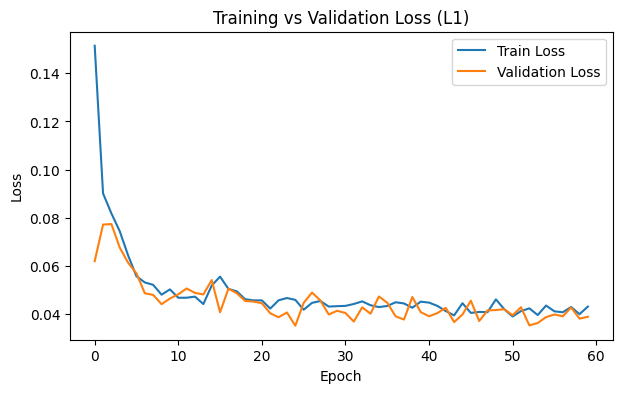

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training vs Validation Loss (L1)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("/content/sr_data/sr_training_curve.png", dpi=150)
plt.show()

Evaluate PSNR & SSIM on validation set

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

model.load_state_dict(torch.load("/content/sr_data/best_espcn.pth"))
model.eval()

psnr_scores, ssim_scores = [], []
bicubic_psnr_scores = []

with torch.no_grad():
    for lr_imgs, hr_imgs in val_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        outputs = model(lr_imgs).clamp(0, 1)

        for i in range(lr_imgs.size(0)):
            hr_np = hr_imgs[i].cpu().permute(1, 2, 0).numpy()
            pred_np = outputs[i].cpu().permute(1, 2, 0).numpy()

            lr_pil = TF.to_pil_image(lr_imgs[i].cpu())
            bicubic_up = lr_pil.resize((hr_np.shape[1], hr_np.shape[0]), Image.BICUBIC)
            bicubic_np = np.array(bicubic_up) / 255.0

            psnr_scores.append(psnr(hr_np, pred_np, data_range=1.0))
            ssim_scores.append(ssim(hr_np, pred_np, channel_axis=2, data_range=1.0))
            bicubic_psnr_scores.append(psnr(hr_np, bicubic_np, data_range=1.0))

print(f"Model   -> PSNR: {np.mean(psnr_scores):.2f} dB | SSIM: {np.mean(ssim_scores):.4f}")
print(f"Bicubic -> PSNR: {np.mean(bicubic_psnr_scores):.2f} dB  (baseline comparison)")

Model   -> PSNR: 26.04 dB | SSIM: 0.7162
Bicubic -> PSNR: 31.02 dB  (baseline comparison)


Visualize results

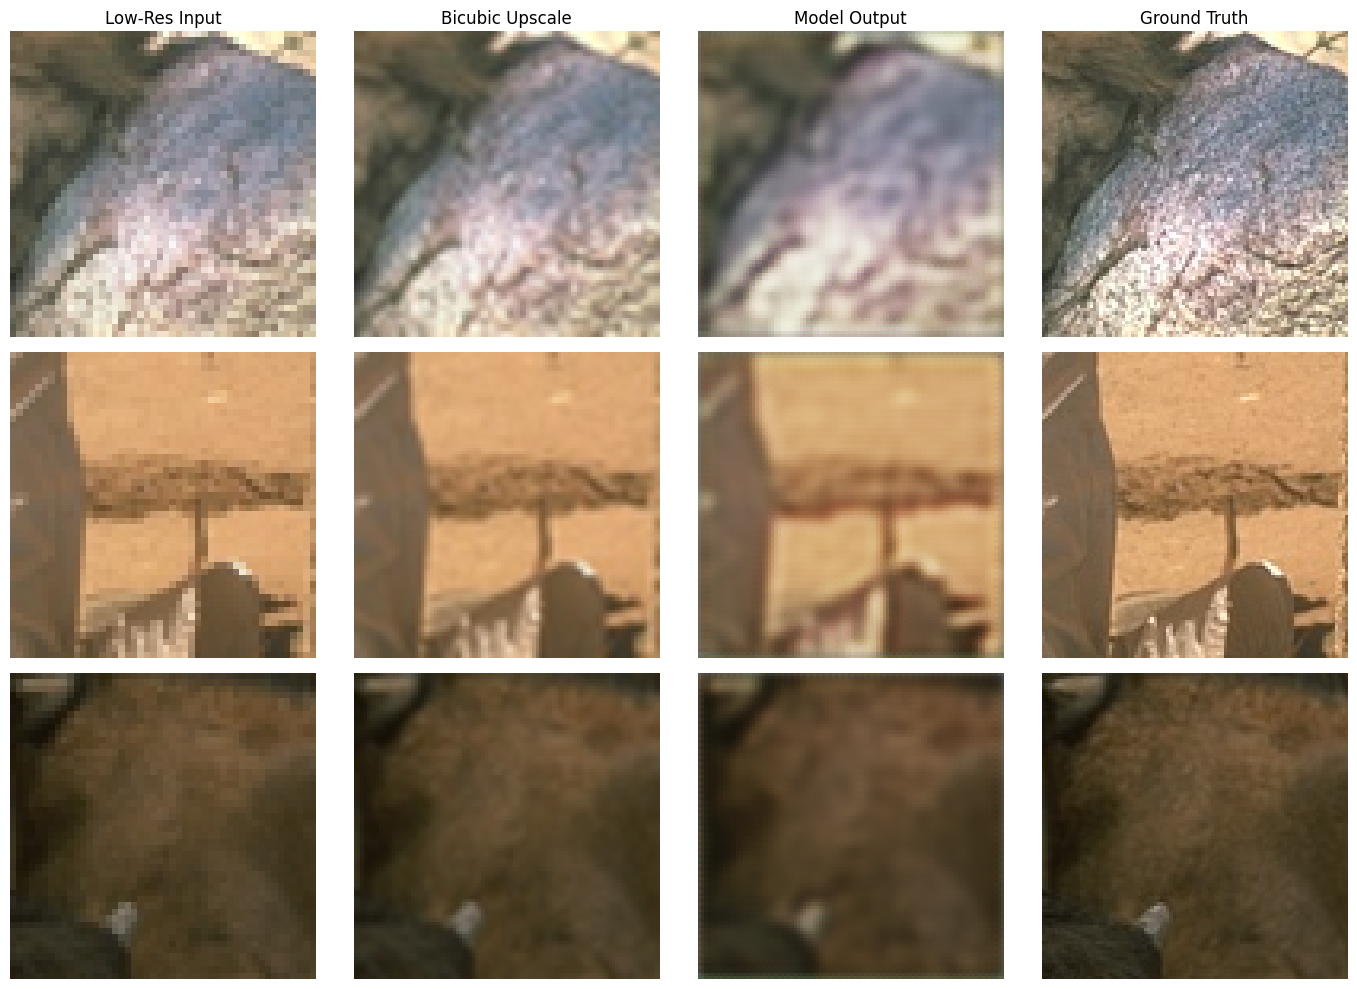

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
col_titles = ["Low-Res Input", "Bicubic Upscale", "Model Output", "Ground Truth"]

with torch.no_grad():
    for i in range(3):
        lr_img, hr_img = val_ds[i]
        lr_img_batch = lr_img.unsqueeze(0).to(device)
        pred = model(lr_img_batch).clamp(0, 1).squeeze(0).cpu()

        lr_pil = TF.to_pil_image(lr_img)
        bicubic_up = lr_pil.resize((hr_img.shape[2], hr_img.shape[1]), Image.BICUBIC)

        axes[i, 0].imshow(lr_pil)
        axes[i, 1].imshow(bicubic_up)
        axes[i, 2].imshow(TF.to_pil_image(pred))
        axes[i, 3].imshow(TF.to_pil_image(hr_img))

        for j, ax in enumerate(axes[i]):
            ax.axis('off')
            if i == 0:
                ax.set_title(col_titles[j])

plt.tight_layout()
plt.savefig("/content/sr_data/sr_predictions.png", dpi=150)
plt.show()

Download Bundle

In [ ]:
from google.colab import files
import shutil

os.makedirs('/content/sr_download_bundle', exist_ok=True)
shutil.copy('/content/sr_data/sr_training_curve.png', '/content/sr_download_bundle/')
shutil.copy('/content/sr_data/sr_predictions.png', '/content/sr_download_bundle/')
shutil.copy('/content/sr_data/best_espcn.pth', '/content/sr_download_bundle/')

shutil.make_archive('/content/sr_bundle', 'zip', '/content/sr_download_bundle')
files.download('/content/sr_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>